In [1]:
import yfinance as yf
import pandas as pd
import time
import logging

In [2]:
logging.basicConfig(
    filename="data_fetch.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

In [3]:
TICKERS = [
    "HDFCBANK.NS",   # Banking
    "TCS.NS",        # IT
    "HINDUNILVR.NS", # FMCG
    "RELIANCE.NS",   # Energy
    "MARUTI.NS",     # Automobile
    "SUNPHARMA.NS",  # Pharma
    "TATASTEEL.NS",  # Metals
    "BHARTIARTL.NS", # Telecom
    "LT.NS",         # Infrastructure
    "DMART.NS",      # Retail
    "^NSEI"          # Indexcv
]

In [4]:
START_DATE = "2018-01-01"
END_DATE = "2023-12-31"

In [5]:
def fetch_with_retry(ticker, retries=3, delay=3):
    for attempt in range(retries):
        try:
            data = yf.download(
                ticker,
                start=START_DATE,
                end=END_DATE,
                progress=False,
                auto_adjust=True
            )

            if data.empty:
                raise ValueError("Empty data returned")

            logging.info(f"Success: {ticker}")
            return data

        except Exception as e:
            logging.warning(f"Attempt {attempt+1} failed for {ticker}: {e}")
            time.sleep(delay)

    logging.error(f"Failed to fetch data for {ticker}")
    return None

In [6]:
def validate_data(df, ticker):
    if df is None:
        return False

    if df.isnull().sum().sum() > 0:
        logging.warning(f"Missing values found in {ticker}")

    return True

In [7]:
import os
os.makedirs("data", exist_ok=True)

def save_data(df, ticker):
    file_path = f"data/{ticker}.csv"
    df.to_csv(file_path)
    logging.info(f"Saved: {file_path}")

In [8]:
all_data = {}
failed_tickers = []

for ticker in TICKERS:
    print(f"Fetching {ticker}...")

    df = fetch_with_retry(ticker)

    if df is not None:

        # Fix multi-index columns
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        # Ensure Close exists
        if 'Close' not in df.columns:
            print(f"Skipping {ticker} - No Close column")
            failed_tickers.append(ticker)
            continue

        if validate_data(df, ticker):
            save_data(df, ticker)
            all_data[ticker] = df
        else:
            failed_tickers.append(ticker)

    else:
        failed_tickers.append(ticker)

    time.sleep(2)

print(" Data collection completed")
print("Successful:", len(all_data))
print("Failed:", failed_tickers)

Fetching HDFCBANK.NS...
Fetching TCS.NS...
Fetching HINDUNILVR.NS...
Fetching RELIANCE.NS...
Fetching MARUTI.NS...
Fetching SUNPHARMA.NS...
Fetching TATASTEEL.NS...
Fetching BHARTIARTL.NS...
Fetching LT.NS...
Fetching DMART.NS...
Fetching ^NSEI...
 Data collection completed
Successful: 11
Failed: []


In [9]:
print(df.head())

Price              Close          High           Low          Open  Volume
Date                                                                      
2018-01-02  10442.200195  10495.200195  10404.650391  10477.549805  153400
2018-01-03  10443.200195  10503.599609  10429.549805  10482.650391  167300
2018-01-04  10504.799805  10513.000000  10441.450195  10469.400391  174900
2018-01-05  10558.849609  10566.099609  10520.099609  10534.250000  180900
2018-01-08  10623.599609  10631.200195  10588.549805  10591.700195  169000


In [10]:
import pandas as pd

price_df = pd.DataFrame()

for ticker, df in all_data.items():
    price_df[ticker] = df['Close']

# Remove missing values
price_df = price_df.dropna()

print(price_df.head())
print(price_df.shape)

            HDFCBANK.NS       TCS.NS  HINDUNILVR.NS  RELIANCE.NS    MARUTI.NS  \
Date                                                                            
2018-01-02   436.853760  1077.872803    1179.038452   402.483215  8871.632812   
2018-01-03   432.257355  1080.924438    1189.387695   404.095581  8744.000977   
2018-01-04   433.948944  1088.482910    1191.061279   406.525055  8715.818359   
2018-01-05   434.812225  1101.632080    1194.848877   407.828156  8760.017578   
2018-01-08   434.112244  1111.955444    1205.286377   410.169342  8774.039062   

            SUNPHARMA.NS  TATASTEEL.NS  BHARTIARTL.NS        LT.NS  \
Date                                                                 
2018-01-02    529.913513     55.824890     443.821136  1108.735229   
2018-01-03    527.042419     56.257374     445.238831  1131.402100   
2018-01-04    538.295532     58.193977     449.362976  1167.243774   
2018-01-05    536.026245     58.993893     463.969421  1166.534058   
2018-01-08  

In [11]:
import numpy as np

# Convert price DataFrame to NumPy array
prices = price_df.values

# Compute log returns
log_returns = np.log(prices[1:] / prices[:-1])

# Convert back to DataFrame (for readability)
log_returns_df = pd.DataFrame(
    log_returns,
    columns=price_df.columns,
    index=price_df.index[1:]
)

# Check output
print(log_returns_df.head())
print(log_returns_df.shape)

            HDFCBANK.NS    TCS.NS  HINDUNILVR.NS  RELIANCE.NS  MARUTI.NS  \
Date                                                                       
2018-01-03    -0.010577  0.002827       0.008739     0.003998  -0.014491   
2018-01-04     0.003906  0.006968       0.001406     0.005994  -0.003228   
2018-01-05     0.001987  0.012008       0.003175     0.003200   0.005058   
2018-01-08    -0.001611  0.009327       0.008697     0.005724   0.001599   
2018-01-09     0.001665 -0.001991      -0.005202     0.013266  -0.006945   

            SUNPHARMA.NS  TATASTEEL.NS  BHARTIARTL.NS     LT.NS  DMART.NS  \
Date                                                                        
2018-01-03     -0.005433      0.007717       0.003189  0.020238  0.020943   
2018-01-04      0.021127      0.033845       0.009220  0.031188  0.015539   
2018-01-05     -0.004225      0.013652       0.031988 -0.000608  0.032948   
2018-01-08      0.021960     -0.002534      -0.044784  0.017602 -0.013440   
2018-

In [12]:
log_returns_df.isnull().sum()

HDFCBANK.NS      0
TCS.NS           0
HINDUNILVR.NS    0
RELIANCE.NS      0
MARUTI.NS        0
SUNPHARMA.NS     0
TATASTEEL.NS     0
BHARTIARTL.NS    0
LT.NS            0
DMART.NS         0
^NSEI            0
dtype: int64

In [13]:
# Mean returns (average daily return of each stock)
mean_returns = np.mean(log_returns, axis=0)

# Covariance matrix (how stocks move together)
cov_matrix = np.cov(log_returns.T)

print("Mean Returns:\n", mean_returns)
print("\nCovariance Matrix shape:", cov_matrix.shape)

Mean Returns:
 [4.36365053e-04 8.04284249e-04 5.25444022e-04 7.85424529e-04
 8.76333967e-05 5.69848429e-04 5.91843566e-04 5.62427902e-04
 7.72243168e-04 8.52524565e-04 4.96546701e-04]

Covariance Matrix shape: (11, 11)


In [14]:
# Simulation settings
num_simulations = 10000
num_days = 252  # trading days in a year

# Equal weights (for now)
num_assets = len(price_df.columns)
weights = np.ones(num_assets) / num_assets

# Initial investment
initial_value = 100000  # ₹1 lakh

# Store final portfolio values
final_values = []

for i in range(num_simulations):

    # Generate random returns (multivariate normal)
    simulated_returns = np.random.multivariate_normal(
        mean_returns,
        cov_matrix,
        num_days
    )

    # Portfolio daily returns
    portfolio_returns = simulated_returns @ weights

    # Convert to cumulative growth
    portfolio_growth = np.exp(np.cumsum(portfolio_returns))

    # Final portfolio value
    final_value = initial_value * portfolio_growth[-1]

    final_values.append(final_value)

# Convert to NumPy array
final_values = np.array(final_values)

print("Simulation complete ")

Simulation complete 


In [15]:
print(len(final_values))

10000


In [16]:
print(final_values[:5])

[113537.23660956 129977.03519805 112673.28115579 102042.69201896
 118415.23020537]


In [17]:
print("Min:", np.min(final_values))
print("Max:", np.max(final_values))

Min: 56169.56571106608
Max: 231113.71722436594


In [18]:
# Expected value
mean_value = np.mean(final_values)

# Median value
median_value = np.median(final_values)

# Best & worst cases
min_value = np.min(final_values)
max_value = np.max(final_values)

# Value at Risk (5%)
var_5 = np.percentile(final_values, 5)

print("Expected Portfolio Value:", mean_value)
print("Median Portfolio Value:", median_value)
print("Worst Case:", min_value)
print("Best Case:", max_value)
print("Value at Risk (5%):", var_5)

Expected Portfolio Value: 117829.95915411673
Median Portfolio Value: 115925.38570019214
Worst Case: 56169.56571106608
Best Case: 231113.71722436594
Value at Risk (5%): 86740.55292859749


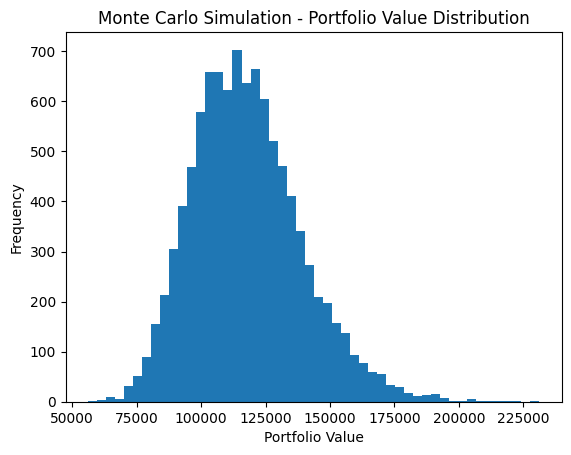

In [19]:
import matplotlib.pyplot as plt

plt.hist(final_values, bins=50)
plt.title("Monte Carlo Simulation - Portfolio Value Distribution")
plt.xlabel("Portfolio Value")
plt.ylabel("Frequency")
plt.show()

In [20]:
from scipy.stats import skew, kurtosis

# --- Simulated portfolio returns ---
simulated_returns = (final_values - initial_value) / initial_value

sim_skew = skew(simulated_returns)
sim_kurt = kurtosis(simulated_returns)

print("Simulated Skewness:", sim_skew)
print("Simulated Kurtosis:", sim_kurt)


# --- Historical portfolio returns ---
# Use same weights
historical_portfolio_returns = log_returns @ weights

hist_skew = skew(historical_portfolio_returns)
hist_kurt = kurtosis(historical_portfolio_returns)

print("\nHistorical Skewness:", hist_skew)
print("Historical Kurtosis:", hist_kurt)

Simulated Skewness: 0.6010868691542293
Simulated Kurtosis: 0.7058485654542075

Historical Skewness: -0.7880416440955872
Historical Kurtosis: 16.720257671224893


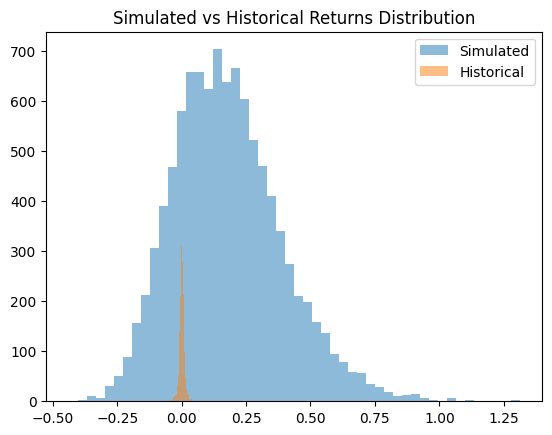

In [21]:
import matplotlib.pyplot as plt

plt.hist(simulated_returns, bins=50, alpha=0.5, label='Simulated')
plt.hist(historical_portfolio_returns, bins=50, alpha=0.5, label='Historical')
plt.legend()
plt.title("Simulated vs Historical Returns Distribution")
plt.show()

In [22]:
import pandas as pd
import numpy as np

# Define if not already set above
num_simulations = 10000
initial_value = 100000

# Save all 10,000 simulation final values
sim_df = pd.DataFrame({
    'simulation_id': range(1, num_simulations + 1),
    'final_value': final_values,
    'return_pct': ((final_values - initial_value) / initial_value) * 100
})

sim_df.to_csv('monte_carlo_simulations.csv', index=False)
print("Saved monte_carlo_simulations.csv")

Saved monte_carlo_simulations.csv


In [23]:
sector_map = {
    'HDFCBANK.NS': 'Banking',
    'ICICIBANK.NS': 'Banking',
    'TCS.NS': 'IT',
    'INFY.NS': 'IT',
    'RELIANCE.NS': 'Energy',
    'SUNPHARMA.NS': 'Pharma',
    'HINDUNILVR.NS': 'FMCG',
    'MARUTI.NS': 'Auto',
    'TATASTEEL.NS': 'Metal',
    'WIPRO.NS': 'IT',
    '^NSEI': 'Index'         
}

stock_summary = pd.DataFrame({
    'ticker': list(sector_map.keys()),
    'sector': list(sector_map.values()),
    'avg_daily_return': mean_returns,
    'volatility': log_returns.std(),
    'weight': [0.1] * 10 + [0.0]   # index has 0 weight
})

stock_summary.to_csv('stock_summary.csv', index=False)
print("Saved stock_summary.csv")

Saved stock_summary.csv


In [24]:
risk_metrics = pd.DataFrame({
    'metric': ['Initial Investment', 'Mean Final Value', 'Median Final Value',
               'Best Case', 'Worst Case', 'VaR 5%'],
    'value': [
        initial_value,
        np.mean(final_values),
        np.median(final_values),
        np.max(final_values),
        np.min(final_values),
        np.percentile(final_values, 5)
    ]
})

risk_metrics.to_csv('risk_metrics.csv', index=False)
print("Saved risk_metrics.csv")

Saved risk_metrics.csv


In [25]:
print(np.percentile(final_values, 5))

86740.55292859749


In [26]:
# Add sector drop impact to simulations
sim_df['IT_adjusted'] = sim_df['final_value'] * (1 + 0/100)  # placeholder
sim_df.to_csv('monte_carlo_simulations.csv', index=False)

In [27]:
# Calculate Max Drawdown
def max_drawdown(final_values):
    peak = np.maximum.accumulate(final_values)
    drawdown = (final_values - peak) / peak
    return drawdown.min() * 100

max_dd = max_drawdown(final_values)
var_5 = np.percentile(final_values, 5)

# Export KPI summary
kpi_df = pd.DataFrame({
    'KPI': ['Current VaR (5%)', 'Max Drawdown', 
            'Expected Return', 'Initial Investment'],
    'Value': [
        round(var_5, 2),
        round(max_dd, 2),
        round(np.mean(final_values), 2),
        100000
    ],
    'Label': [
        f"₹{var_5:,.0f}",
        f"{max_dd:.1f}%",
        f"₹{np.mean(final_values):,.0f}",
        "₹1,00,000"
    ]
})

kpi_df.to_csv('kpi_summary.csv', index=False)
print("✅ KPI Summary exported!")
print(kpi_df)

✅ KPI Summary exported!
                  KPI      Value      Label
0    Current VaR (5%)   86740.55    ₹86,741
1        Max Drawdown     -74.74     -74.7%
2     Expected Return  117829.96   ₹117,830
3  Initial Investment  100000.00  ₹1,00,000
